In [1]:
# Import core libraries used throughout the notebook

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TASK 1

In [2]:
# Load the raw Online Retail dataset and preview the first rows

df = pd.read_excel("Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
# Check the dimensions of the dataset (rows, columns)

df.shape

(541909, 8)

In [4]:
# Inspect column names, data types and non-null counts

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [5]:
# Descriptive statistics for the numerical columns

df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [6]:
# Calculate central tendency and dispersion measures for Quantity and UnitPrice

print("Mean: ", df[['Quantity', 'UnitPrice']].mean())
print("Median: ", df[['Quantity', 'UnitPrice']].median())
print("Mode: ", df[['Quantity', 'UnitPrice']].mode().iloc[0])
print("Range: ", df[['Quantity', 'UnitPrice']].max() - df[['Quantity', 'UnitPrice']].min())
print("Standard Deviation: ", df[['Quantity', 'UnitPrice']].std())
print("Variance: ", df[['Quantity', 'UnitPrice']].var())
print("Quartiles: ", df[['Quantity', 'UnitPrice']].quantile([0.25, 0.50, 0.75]))
print("Interquartile Range: ", df[['Quantity', 'UnitPrice']].quantile(0.75) - df[['Quantity', 'UnitPrice']].quantile(0.25))

Mean:  Quantity     9.552250
UnitPrice    4.611114
dtype: float64
Median:  Quantity     3.00
UnitPrice    2.08
dtype: float64
Mode:  Quantity     1.00
UnitPrice    1.25
Name: 0, dtype: float64
Range:  Quantity     161990.00
UnitPrice     50032.06
dtype: float64
Standard Deviation:  Quantity     218.081158
UnitPrice     96.759853
dtype: float64
Variance:  Quantity     47559.391409
UnitPrice     9362.469164
dtype: float64
Quartiles:        Quantity  UnitPrice
0.25       1.0       1.25
0.50       3.0       2.08
0.75      10.0       4.13
Interquartile Range:  Quantity     9.00
UnitPrice    2.88
dtype: float64


In [7]:
# Preview the feature matrix X and target vector y for the planned modelling task

# Example of feature matrix X
X = df[['Quantity', 'UnitPrice']]

# Example of target vector y
y = df['Quantity']

print("Feature matrix X:")
print(X.head())

print("\nTarget vector y:")
print(y.head())

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

Feature matrix X:
   Quantity  UnitPrice
0         6       2.55
1         6       3.39
2         8       2.75
3         6       3.39
4         6       3.39

Target vector y:
0    6
1    6
2    8
3    6
4    6
Name: Quantity, dtype: int64

Shape of X: (541909, 2)
Shape of y: (541909,)


# TASK 2

In [8]:
# Count missing values per column

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [9]:
# Missing values summary as counts and percentages

# Check for missing values
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)


# Calculate missing values and their percentage
missing_summary = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': (df.isnull().sum() / len(df)) * 100
})

missing_summary['Percentage'] = missing_summary['Percentage'].round(2)

print("\nMissing value summary:")
print(missing_summary)

Missing values in each column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Missing value summary:
             Missing Values  Percentage
InvoiceNo                 0        0.00
StockCode                 0        0.00
Description            1454        0.27
Quantity                  0        0.00
InvoiceDate               0        0.00
UnitPrice                 0        0.00
CustomerID           135080       24.93
Country                   0        0.00


In [10]:
# Compare number of transactions with and without CustomerID

customer_id_missing = df['CustomerID'].isnull()

print("Transactions with CustomerID:")
print(df[~customer_id_missing].shape[0])

print("\nTransactions without CustomerID:")
print(df[customer_id_missing].shape[0])

Transactions with CustomerID:
406829

Transactions without CustomerID:
135080


In [11]:
# Compare Quantity/UnitPrice statistics for records with vs. without CustomerID

print("With CustomerID:")
print(df[~customer_id_missing][['Quantity', 'UnitPrice']].describe())

print("\nWithout CustomerID:")
print(df[customer_id_missing][['Quantity', 'UnitPrice']].describe())

With CustomerID:
            Quantity      UnitPrice
count  406829.000000  406829.000000
mean       12.061303       3.460471
std       248.693370      69.315162
min    -80995.000000       0.000000
25%         2.000000       1.250000
50%         5.000000       1.950000
75%        12.000000       3.750000
max     80995.000000   38970.000000

Without CustomerID:
            Quantity      UnitPrice
count  135080.000000  135080.000000
mean        1.995573       8.076577
std        66.696153     151.900816
min     -9600.000000  -11062.060000
25%         1.000000       1.630000
50%         1.000000       3.290000
75%         3.000000       5.450000
max      5568.000000   17836.460000


In [12]:
# Inspect records with a missing Description

description_missing = df['Description'].isnull()

print("Records with missing Description:")
print(df[description_missing].shape[0])

print("\nSample of records with missing Description:")
print(df[description_missing].head(10))

Records with missing Description:
1454

Sample of records with missing Description:
     InvoiceNo StockCode Description  Quantity         InvoiceDate  UnitPrice  \
622     536414     22139         NaN        56 2010-12-01 11:52:00        0.0   
1970    536545     21134         NaN         1 2010-12-01 14:32:00        0.0   
1971    536546     22145         NaN         1 2010-12-01 14:33:00        0.0   
1972    536547     37509         NaN         1 2010-12-01 14:33:00        0.0   
1987    536549    85226A         NaN         1 2010-12-01 14:34:00        0.0   
1988    536550     85044         NaN         1 2010-12-01 14:34:00        0.0   
2024    536552     20950         NaN         1 2010-12-01 14:34:00        0.0   
2025    536553     37461         NaN         3 2010-12-01 14:35:00        0.0   
2026    536554     84670         NaN        23 2010-12-01 14:35:00        0.0   
2406    536589     21777         NaN       -10 2010-12-01 16:50:00        0.0   

      CustomerID        

In [13]:
# Count exact duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 5268


In [14]:
# Preview a sample of the duplicate rows

duplicates = df[df.duplicated(keep=False)]

print("Sample of duplicate records:")
print(duplicates.head(20))

Sample of duplicate records:
    InvoiceNo StockCode                        Description  Quantity  \
485    536409     22111       SCOTTIE DOG HOT WATER BOTTLE         1   
489    536409     22866      HAND WARMER SCOTTY DOG DESIGN         1   
494    536409     21866        UNION JACK FLAG LUGGAGE TAG         1   
517    536409     21866        UNION JACK FLAG LUGGAGE TAG         1   
521    536409     22900    SET 2 TEA TOWELS I LOVE LONDON          1   
527    536409     22866      HAND WARMER SCOTTY DOG DESIGN         1   
537    536409     22900    SET 2 TEA TOWELS I LOVE LONDON          1   
539    536409     22111       SCOTTIE DOG HOT WATER BOTTLE         1   
548    536412     22327  ROUND SNACK BOXES SET OF 4 SKULLS         1   
555    536412     22327  ROUND SNACK BOXES SET OF 4 SKULLS         1   
556    536412     22273               FELTCRAFT DOLL MOLLY         1   
565    536412     21448          12 DAISY PEGS IN WOOD BOX         2   
569    536412     22749  FELTCRAFT 

In [15]:
# Remove exact duplicate rows and store the result in df_clean

df_clean = df.drop_duplicates().copy()

print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)
print("Rows removed:", df.shape[0] - df_clean.shape[0])

Original dataset shape: (541909, 8)
Cleaned dataset shape: (536641, 8)
Rows removed: 5268


In [16]:
# Confirm no duplicate rows remain after cleaning

print("Duplicate records after cleaning:", df_clean.duplicated().sum())

Duplicate records after cleaning: 0


In [17]:
# Identify cancelled transactions (InvoiceNo starting with 'C')

cancelled_transactions = df_clean['InvoiceNo'].astype(str).str.startswith('C')

print("Number of cancelled transaction rows:", cancelled_transactions.sum())
print("Percentage of cancelled transaction rows:",
      round(cancelled_transactions.mean() * 100, 2), "%")

Number of cancelled transaction rows: 9251
Percentage of cancelled transaction rows: 1.72 %


In [18]:
# Compare Quantity statistics for cancelled vs. non-cancelled transactions

print("Cancelled transactions:")
print(df_clean[cancelled_transactions]['Quantity'].describe())

print("\nNon-cancelled transactions:")
print(df_clean[~cancelled_transactions]['Quantity'].describe())

Cancelled transactions:
count     9251.000000
mean       -29.787050
std       1147.997592
min     -80995.000000
25%         -6.000000
50%         -2.000000
75%         -1.000000
max         -1.000000
Name: Quantity, dtype: float64

Non-cancelled transactions:
count    527390.000000
mean         10.311272
std         160.367285
min       -9600.000000
25%           1.000000
50%           3.000000
75%          11.000000
max       80995.000000
Name: Quantity, dtype: float64


In [19]:
# Check the sign of Quantity within cancelled transactions

negative_cancelled = (
    df_clean[cancelled_transactions]['Quantity'] < 0
).sum()

positive_cancelled = (
    df_clean[cancelled_transactions]['Quantity'] > 0
).sum()

zero_cancelled = (
    df_clean[cancelled_transactions]['Quantity'] == 0
).sum()

print("Cancelled transactions with negative Quantity:", negative_cancelled)
print("Cancelled transactions with positive Quantity:", positive_cancelled)
print("Cancelled transactions with zero Quantity:", zero_cancelled)

Cancelled transactions with negative Quantity: 9251
Cancelled transactions with positive Quantity: 0
Cancelled transactions with zero Quantity: 0


In [20]:
# Check for negative Quantity values outside cancelled transactions

negative_non_cancelled = (
    df_clean[~cancelled_transactions]['Quantity'] < 0
)

print("Negative quantities in non-cancelled transactions:",
      negative_non_cancelled.sum())

print("Percentage of non-cancelled transactions with negative Quantity:",
      round(negative_non_cancelled.mean() * 100, 2), "%")

Negative quantities in non-cancelled transactions: 1336
Percentage of non-cancelled transactions with negative Quantity: 0.25 %


In [21]:
# Preview non-cancelled transactions with negative Quantity

print(df_clean[
    (~cancelled_transactions) &
    (df_clean['Quantity'] < 0)
].head(20))

     InvoiceNo StockCode Description  Quantity         InvoiceDate  UnitPrice  \
2406    536589     21777         NaN       -10 2010-12-01 16:50:00        0.0   
4347    536764    84952C         NaN       -38 2010-12-02 14:42:00        0.0   
7188    536996     22712         NaN       -20 2010-12-03 15:30:00        0.0   
7189    536997     22028         NaN       -20 2010-12-03 15:30:00        0.0   
7190    536998     85067         NaN        -6 2010-12-03 15:30:00        0.0   
7192    537000     21414         NaN       -22 2010-12-03 15:32:00        0.0   
7193    537001     21653         NaN        -6 2010-12-03 15:33:00        0.0   
7195    537003     85126         NaN        -2 2010-12-03 15:33:00        0.0   
7196    537004     21814         NaN       -30 2010-12-03 15:34:00        0.0   
7197    537005     21692         NaN       -70 2010-12-03 15:35:00        0.0   
7198    537006     21648         NaN      -130 2010-12-03 15:36:00        0.0   
7199    537007     21172    

In [22]:
# Check whether these negative, non-cancelled quantities also have UnitPrice = 0

negative_non_cancelled_data = df_clean[
    (~cancelled_transactions) &
    (df_clean['Quantity'] < 0)
]

print("UnitPrice values for negative quantities:")
print(negative_non_cancelled_data['UnitPrice'].value_counts().head(10))

print("\nNumber of negative-quantity records with UnitPrice = 0:",
      (negative_non_cancelled_data['UnitPrice'] == 0).sum())

print("Number of negative-quantity records with UnitPrice > 0:",
      (negative_non_cancelled_data['UnitPrice'] > 0).sum())

UnitPrice values for negative quantities:
UnitPrice
0.0    1336
Name: count, dtype: int64

Number of negative-quantity records with UnitPrice = 0: 1336
Number of negative-quantity records with UnitPrice > 0: 0


In [23]:
# Remove negative-quantity records that are not cancellations and have UnitPrice = 0 (data errors)

invalid_negative = (
    (~cancelled_transactions) &
    (df_clean['Quantity'] < 0) &
    (df_clean['UnitPrice'] == 0)
)

df_clean = df_clean[~invalid_negative].copy()

print("Rows removed:", invalid_negative.sum())
print("Dataset shape after removing invalid negative quantities:", df_clean.shape)

Rows removed: 1336
Dataset shape after removing invalid negative quantities: (535305, 8)


In [24]:
# Count transactions with UnitPrice equal to 0 or negative

zero_price = (df_clean['UnitPrice'] == 0).sum()
negative_price = (df_clean['UnitPrice'] < 0).sum()

print("Transactions with UnitPrice = 0:", zero_price)
print("Transactions with UnitPrice < 0:", negative_price)

Transactions with UnitPrice = 0: 1174
Transactions with UnitPrice < 0: 2


In [25]:
# Preview transactions with UnitPrice = 0

zero_price_records = df_clean[df_clean['UnitPrice'] == 0]

print("Sample of transactions with UnitPrice = 0:")
print(zero_price_records.head(20))

Sample of transactions with UnitPrice = 0:
      InvoiceNo StockCode                   Description  Quantity  \
622      536414     22139                           NaN        56   
1970     536545     21134                           NaN         1   
1971     536546     22145                           NaN         1   
1972     536547     37509                           NaN         1   
1987     536549    85226A                           NaN         1   
1988     536550     85044                           NaN         1   
2024     536552     20950                           NaN         1   
2025     536553     37461                           NaN         3   
2026     536554     84670                           NaN        23   
4348     536765    84952C                           NaN        19   
6391     536941     22734                        amazon        20   
6392     536942     22139                        amazon        15   
7187     536995     35951                           NaN     

In [26]:
# Preview transactions with negative UnitPrice

negative_price_records = df_clean[df_clean['UnitPrice'] < 0]

print("Transactions with negative UnitPrice:")
print(negative_price_records)

Transactions with negative UnitPrice:
       InvoiceNo StockCode      Description  Quantity         InvoiceDate  \
299983   A563186         B  Adjust bad debt         1 2011-08-12 14:51:00   
299984   A563187         B  Adjust bad debt         1 2011-08-12 14:52:00   

        UnitPrice  CustomerID         Country  
299983  -11062.06         NaN  United Kingdom  
299984  -11062.06         NaN  United Kingdom  


In [27]:
# Remove the remaining negative UnitPrice records (accounting adjustments)

negative_price = df_clean['UnitPrice'] < 0

df_clean = df_clean[~negative_price].copy()

print("Rows removed:", negative_price.sum())
print("Dataset shape after removing negative prices:", df_clean.shape)

Rows removed: 2
Dataset shape after removing negative prices: (535303, 8)


In [28]:
# Confirm no negative UnitPrice values remain

print("Negative UnitPrice values after cleaning:",
      (df_clean['UnitPrice'] < 0).sum())

Negative UnitPrice values after cleaning: 0


In [29]:
# Calculate Q1, Q3, IQR and outlier bounds for Quantity and UnitPrice

Q1 = df_clean[['Quantity', 'UnitPrice']].quantile(0.25)
Q3 = df_clean[['Quantity', 'UnitPrice']].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:")
print(Q1)

print("\nQ3:")
print(Q3)

print("\nIQR:")
print(IQR)

print("\nLower bounds:")
print(lower_bound)

print("\nUpper bounds:")
print(upper_bound)

Q1:
Quantity     1.00
UnitPrice    1.25
Name: 0.25, dtype: float64

Q3:
Quantity     10.00
UnitPrice     4.13
Name: 0.75, dtype: float64

IQR:
Quantity     9.00
UnitPrice    2.88
dtype: float64

Lower bounds:
Quantity    -12.50
UnitPrice    -3.07
dtype: float64

Upper bounds:
Quantity     23.50
UnitPrice     8.45
dtype: float64


In [30]:
# Count how many values fall outside the IQR bounds (potential outliers)

quantity_outliers = (
    (df_clean['Quantity'] < lower_bound['Quantity']) |
    (df_clean['Quantity'] > upper_bound['Quantity'])
)

price_outliers = (
    (df_clean['UnitPrice'] < lower_bound['UnitPrice']) |
    (df_clean['UnitPrice'] > upper_bound['UnitPrice'])
)

print("Potential Quantity outliers:", quantity_outliers.sum())
print("Percentage of Quantity outliers:",
      round(quantity_outliers.mean() * 100, 2), "%")

print("\nPotential UnitPrice outliers:", price_outliers.sum())
print("Percentage of UnitPrice outliers:",
      round(price_outliers.mean() * 100, 2), "%")

Potential Quantity outliers: 57598
Percentage of Quantity outliers: 10.76 %

Potential UnitPrice outliers: 39448
Percentage of UnitPrice outliers: 7.37 %


In [31]:
# Inspect the most extreme Quantity and UnitPrice values

print("Extreme Quantity values:")
print(
    df_clean.loc[quantity_outliers, ['InvoiceNo', 'StockCode',
                                     'Description', 'Quantity',
                                     'UnitPrice', 'CustomerID',
                                     'Country']].sort_values(
                                         'Quantity',
                                         ascending=False
                                     ).head(20)
)

print("\nExtreme UnitPrice values:")
print(
    df_clean.loc[price_outliers, ['InvoiceNo', 'StockCode',
                                  'Description', 'Quantity',
                                  'UnitPrice', 'CustomerID',
                                  'Country']].sort_values(
                                      'UnitPrice',
                                      ascending=False
                                  ).head(20)
)

Extreme Quantity values:
       InvoiceNo StockCode                          Description  Quantity  \
540421    581483     23843          PAPER CRAFT , LITTLE BIRDIE     80995   
61619     541431     23166       MEDIUM CERAMIC TOP STORAGE JAR     74215   
502122    578841     84826       ASSTD DESIGN 3D PAPER STICKERS     12540   
74614     542504     37413                                  NaN      5568   
421632    573008     84077    WORLD WAR 2 GLIDERS ASSTD DESIGNS      4800   
206121    554868     22197                 SMALL POPCORN HOLDER      4300   
220843    556231    85123A                                    ?      4000   
97432     544612     22053                EMPIRE DESIGN ROSETTE      3906   
270885    560599     18007  ESSENTIAL BALM 3.5g TIN IN ENVELOPE      3186   
52711     540815     21108   FAIRY CAKE FLANNEL ASSORTED COLOUR      3114   
160546    550461     21108   FAIRY CAKE FLANNEL ASSORTED COLOUR      3114   
263885    560040     23343                  came co

In [32]:
# Check data types after cleaning

print("Data types after cleaning:")
print(df_clean.dtypes)

Data types after cleaning:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object


In [33]:
# Preview CustomerID values and count unique customers

print("Sample CustomerID values:")
print(df_clean['CustomerID'].dropna().head(10).tolist())

print("\nNumber of unique CustomerIDs:")
print(df_clean['CustomerID'].nunique())

Sample CustomerID values:
[17850.0, 17850.0, 17850.0, 17850.0, 17850.0, 17850.0, 17850.0, 17850.0, 17850.0, 13047.0]

Number of unique CustomerIDs:
4372


In [34]:
# Convert CustomerID from float to Int64 (nullable integer identifier)

df_clean['CustomerID'] = df_clean['CustomerID'].astype('Int64')

print("Data types after converting CustomerID:")
print(df_clean.dtypes)

Data types after converting CustomerID:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID              Int64
Country                   str
dtype: object


In [35]:
# Confirm CustomerID values after conversion

print("Sample CustomerID values:")
print(df_clean['CustomerID'].dropna().head(10).tolist())

Sample CustomerID values:
[17850, 17850, 17850, 17850, 17850, 17850, 17850, 17850, 17850, 13047]


In [36]:
# Create the TotalPrice feature (Quantity x UnitPrice)

df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

print("First rows with TotalPrice:")
print(df_clean[['Quantity', 'UnitPrice', 'TotalPrice']].head())

First rows with TotalPrice:
   Quantity  UnitPrice  TotalPrice
0         6       2.55       15.30
1         6       3.39       20.34
2         8       2.75       22.00
3         6       3.39       20.34
4         6       3.39       20.34


In [37]:
# Descriptive statistics for TotalPrice, including negative and zero values

print("TotalPrice statistics:")
print(df_clean['TotalPrice'].describe())

print("\nMinimum TotalPrice:", df_clean['TotalPrice'].min())
print("Maximum TotalPrice:", df_clean['TotalPrice'].max())

print("\nNumber of negative TotalPrice values:",
      (df_clean['TotalPrice'] < 0).sum())

print("Number of zero TotalPrice values:",
      (df_clean['TotalPrice'] == 0).sum())

TotalPrice statistics:
count    535303.000000
mean         18.210492
std         380.528378
min     -168469.600000
25%           3.750000
50%           9.900000
75%          17.400000
max      168469.600000
Name: TotalPrice, dtype: float64

Minimum TotalPrice: -168469.6
Maximum TotalPrice: 168469.6

Number of negative TotalPrice values: 9251
Number of zero TotalPrice values: 1174


In [38]:
# Extract InvoiceMonth, InvoiceDay and InvoiceHour from InvoiceDate

df_clean['InvoiceMonth'] = df_clean['InvoiceDate'].dt.month
df_clean['InvoiceDay'] = df_clean['InvoiceDate'].dt.day
df_clean['InvoiceHour'] = df_clean['InvoiceDate'].dt.hour

print("First rows with temporal features:")
print(
    df_clean[
        ['InvoiceDate', 'InvoiceMonth', 'InvoiceDay', 'InvoiceHour']
    ].head()
)

First rows with temporal features:
          InvoiceDate  InvoiceMonth  InvoiceDay  InvoiceHour
0 2010-12-01 08:26:00            12           1            8
1 2010-12-01 08:26:00            12           1            8
2 2010-12-01 08:26:00            12           1            8
3 2010-12-01 08:26:00            12           1            8
4 2010-12-01 08:26:00            12           1            8


In [39]:
# Sanity-check the range of the new time-based features

print("InvoiceMonth range:",
      df_clean['InvoiceMonth'].min(),
      "to",
      df_clean['InvoiceMonth'].max())

print("InvoiceDay range:",
      df_clean['InvoiceDay'].min(),
      "to",
      df_clean['InvoiceDay'].max())

print("InvoiceHour range:",
      df_clean['InvoiceHour'].min(),
      "to",
      df_clean['InvoiceHour'].max())

InvoiceMonth range: 1 to 12
InvoiceDay range: 1 to 31
InvoiceHour range: 6 to 20


In [40]:
# Keep only transactions with a valid CustomerID for customer-level analysis

customer_data = df_clean[df_clean['CustomerID'].notna()].copy()

print("Rows available for customer-level analysis:", len(customer_data))
print("Unique customers:", customer_data['CustomerID'].nunique())

Rows available for customer-level analysis: 401604
Unique customers: 4372


In [41]:
# Define the reference date for Recency (most recent invoice date + 1 day)

reference_date = customer_data['InvoiceDate'].max() + pd.Timedelta(days=1)

print("Latest transaction date:", customer_data['InvoiceDate'].max())
print("Reference date:", reference_date)

Latest transaction date: 2011-12-09 12:50:00
Reference date: 2011-12-10 12:50:00


In [42]:
# Calculate Recency, Frequency and Monetary per customer (RFM)

rfm = customer_data.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

print("RFM dataset shape:", rfm.shape)
print("\nFirst five customers:")
print(rfm.head())

RFM dataset shape: (4372, 4)

First five customers:
   CustomerID  Recency  Frequency  Monetary
0       12346      326          2      0.00
1       12347        2          7   4310.00
2       12348       75          4   1797.24
3       12349       19          1   1757.55
4       12350      310          1    334.40


In [43]:
# Calculate AverageBasket = Monetary / Frequency

rfm['AverageBasket'] = rfm['Monetary'] / rfm['Frequency']

print("RFM dataset with AverageBasket:")
print(rfm.head())

RFM dataset with AverageBasket:
   CustomerID  Recency  Frequency  Monetary  AverageBasket
0       12346      326          2      0.00       0.000000
1       12347        2          7   4310.00     615.714286
2       12348       75          4   1797.24     449.310000
3       12349       19          1   1757.55    1757.550000
4       12350      310          1    334.40     334.400000


In [44]:
# Check AverageBasket for missing or infinite values

print("AverageBasket statistics:")
print(rfm['AverageBasket'].describe())

print("\nMissing AverageBasket values:",
      rfm['AverageBasket'].isnull().sum())

print("Infinite AverageBasket values:",
      np.isinf(rfm['AverageBasket']).sum())

AverageBasket statistics:
count    4372.000000
mean      314.492693
std       360.855433
min     -4287.630000
25%       151.430000
50%       235.154111
75%       366.518750
max      6207.670000
Name: AverageBasket, dtype: float64

Missing AverageBasket values: 0
Infinite AverageBasket values: 0


In [45]:
# Identify customers with negative Monetary value (returns exceed purchases)

negative_monetary = rfm[rfm['Monetary'] < 0]

print("Customers with negative Monetary:", len(negative_monetary))
print("Percentage of customers with negative Monetary:",
      round(len(negative_monetary) / len(rfm) * 100, 2), "%")

print("\nCustomers with negative Monetary:")
print(negative_monetary.head(10))

Customers with negative Monetary: 42
Percentage of customers with negative Monetary: 0.96 %

Customers with negative Monetary:
      CustomerID  Recency  Frequency  Monetary  AverageBasket
125        12503      338          1  -1126.00       -1126.00
127        12505      301          1     -4.50          -4.50
212        12605      365          1     -7.50          -7.50
264        12666      359          1   -227.44        -227.44
415        12870      366          1    -14.90         -14.90
467        12943      301          1     -3.75          -3.75
619        13154      144          1   -611.86        -611.86
991        13672      301          6    -71.46         -11.91
1004       13693      325          2    -32.00         -16.00
1106       13829      359          1   -102.00        -102.00


In [46]:
# Calculate UniqueProducts per customer

unique_products = customer_data.groupby('CustomerID')['StockCode'].nunique()

rfm['UniqueProducts'] = rfm['CustomerID'].map(unique_products)

print("RFM dataset with UniqueProducts:")
print(rfm.head())

RFM dataset with UniqueProducts:
   CustomerID  Recency  Frequency  Monetary  AverageBasket  UniqueProducts
0       12346      326          2      0.00       0.000000               1
1       12347        2          7   4310.00     615.714286             103
2       12348       75          4   1797.24     449.310000              22
3       12349       19          1   1757.55    1757.550000              73
4       12350      310          1    334.40     334.400000              17


In [47]:
# Check UniqueProducts for missing values

print("UniqueProducts statistics:")
print(rfm['UniqueProducts'].describe())

print("\nMissing UniqueProducts values:",
      rfm['UniqueProducts'].isnull().sum())

UniqueProducts statistics:
count    4372.000000
mean       61.211116
std        85.425119
min         1.000000
25%        15.000000
50%        35.000000
75%        77.000000
max      1794.000000
Name: UniqueProducts, dtype: float64

Missing UniqueProducts values: 0


In [48]:
# Summary statistics for all customer-level features

customer_features = [
    'Recency',
    'Frequency',
    'Monetary',
    'AverageBasket',
    'UniqueProducts'
]

print("Customer-level feature statistics:")
print(rfm[customer_features].describe())

Customer-level feature statistics:
           Recency    Frequency       Monetary  AverageBasket  UniqueProducts
count  4372.000000  4372.000000    4372.000000    4372.000000     4372.000000
mean     92.047118     5.075480    1893.531433     314.492693       61.211116
std     100.765435     9.338754    8218.696204     360.855433       85.425119
min       1.000000     1.000000   -4287.630000   -4287.630000        1.000000
25%      17.000000     1.000000     291.795000     151.430000       15.000000
50%      50.000000     3.000000     644.070000     235.154111       35.000000
75%     143.000000     5.000000    1608.335000     366.518750       77.000000
max     374.000000   248.000000  279489.020000    6207.670000     1794.000000


In [49]:
# Standardise the customer-level features with StandardScaler

from sklearn.preprocessing import StandardScaler

features_to_scale = [
    'Recency',
    'Frequency',
    'Monetary',
    'AverageBasket',
    'UniqueProducts'
]

# Standardise the selected features
scaler = StandardScaler()

rfm_scaled = rfm.copy()
rfm_scaled[features_to_scale] = scaler.fit_transform(
    rfm[features_to_scale]
)

print("Standardised customer features:")
print(rfm_scaled[features_to_scale].head())

Standardised customer features:
    Recency  Frequency  Monetary  AverageBasket  UniqueProducts
0  2.322023  -0.329362 -0.230420      -0.871620       -0.704922
1 -0.893733   0.206102  0.294055       0.834839        0.489243
2 -0.169196  -0.115176 -0.011717       0.373647       -0.459064
3 -0.725005  -0.436455 -0.016547       3.999448        0.138018
4  2.163220  -0.436455 -0.189727       0.055173       -0.517602


In [50]:
# Confirm standardisation: means close to 0 and standard deviations close to 1

print("Means after standardisation:")
print(rfm_scaled[features_to_scale].mean().round(2))

print("\nStandard deviations after standardisation:")
print(rfm_scaled[features_to_scale].std().round(2))

Means after standardisation:
Recency          -0.0
Frequency         0.0
Monetary          0.0
AverageBasket    -0.0
UniqueProducts    0.0
dtype: float64

Standard deviations after standardisation:
Recency           1.0
Frequency         1.0
Monetary          1.0
AverageBasket     1.0
UniqueProducts    1.0
dtype: float64


In [51]:
# Calculate the Euclidean distance between two example customers using the scaled features

from scipy.spatial.distance import euclidean

# Select two customers
customer_1 = rfm_scaled.loc[rfm_scaled['CustomerID'] == 12347, features_to_scale].iloc[0]
customer_2 = rfm_scaled.loc[rfm_scaled['CustomerID'] == 12348, features_to_scale].iloc[0]

# Calculate Euclidean distance
distance = euclidean(customer_1, customer_2)

print("Customer 12347 standardized features:")
print(customer_1)

print("\nCustomer 12348 standardized features:")
print(customer_2)

print("\nEuclidean distance between the two customers:",
      round(distance, 4))

Customer 12347 standardized features:
Recency          -0.893733
Frequency         0.206102
Monetary          0.294055
AverageBasket     0.834839
UniqueProducts    0.489243
Name: 1, dtype: float64

Customer 12348 standardized features:
Recency          -0.169196
Frequency        -0.115176
Monetary         -0.011717
AverageBasket     0.373647
UniqueProducts   -0.459064
Name: 2, dtype: float64

Euclidean distance between the two customers: 1.3541


In [52]:
# Check how many unique countries are in the dataset

print("Number of unique countries:", df_clean['Country'].nunique())

print("\nCountries:")
print(df_clean['Country'].unique())

Number of unique countries: 38

Countries:
<StringArray>
[      'United Kingdom',               'France',            'Australia',
          'Netherlands',              'Germany',               'Norway',
                 'EIRE',          'Switzerland',                'Spain',
               'Poland',             'Portugal',                'Italy',
              'Belgium',            'Lithuania',                'Japan',
              'Iceland',      'Channel Islands',              'Denmark',
               'Cyprus',               'Sweden',              'Austria',
               'Israel',              'Finland',              'Bahrain',
               'Greece',            'Hong Kong',            'Singapore',
              'Lebanon', 'United Arab Emirates',         'Saudi Arabia',
       'Czech Republic',               'Canada',          'Unspecified',
               'Brazil',                  'USA',   'European Community',
                'Malta',                  'RSA']
Length: 38, dtype:

In [53]:
# One-hot encode the Country variable

df_encoded = df_clean.copy()

# Apply one-hot encoding to the Country variable
df_encoded = pd.get_dummies(
    df_encoded,
    columns=['Country'],
    dtype=int
)

print("Original number of columns:", df_clean.shape[1])
print("Number of columns after encoding:", df_encoded.shape[1])

print("\nEncoded country columns:")
print([col for col in df_encoded.columns if col.startswith('Country_')][:10])

Original number of columns: 12
Number of columns after encoding: 49

Encoded country columns:
['Country_Australia', 'Country_Austria', 'Country_Bahrain', 'Country_Belgium', 'Country_Brazil', 'Country_Canada', 'Country_Channel Islands', 'Country_Cyprus', 'Country_Czech Republic', 'Country_Denmark']


In [54]:
# Verify the encoding by comparing original and encoded country columns

print(df_clean[['Country']].head())

print("\nEncoded country columns for the same rows:")
country_columns = [
    col for col in df_encoded.columns
    if col.startswith('Country_')
]

print(df_encoded[country_columns].head())

          Country
0  United Kingdom
1  United Kingdom
2  United Kingdom
3  United Kingdom
4  United Kingdom

Encoded country columns for the same rows:
   Country_Australia  Country_Austria  Country_Bahrain  Country_Belgium  \
0                  0                0                0                0   
1                  0                0                0                0   
2                  0                0                0                0   
3                  0                0                0                0   
4                  0                0                0                0   

   Country_Brazil  Country_Canada  Country_Channel Islands  Country_Cyprus  \
0               0               0                        0               0   
1               0               0                        0               0   
2               0               0                        0               0   
3               0               0                        0               0   
4      

In [55]:
# Summary of dataset size at each cleaning/feature-engineering stage

preprocessing_summary = pd.DataFrame({
    'Stage': [
        'Original dataset',
        'After removing exact duplicates',
        'After removing invalid records',
        'After feature engineering'
    ],
    'Rows': [
        541909,
        536641,
        535303,
        len(df_clean)
    ],
    'Columns': [
        8,
        8,
        8,
        df_clean.shape[1]
    ]
})

print(preprocessing_summary)

                             Stage    Rows  Columns
0                 Original dataset  541909        8
1  After removing exact duplicates  536641        8
2   After removing invalid records  535303        8
3        After feature engineering  535303       12


# TASK 3

In [56]:
# Define target Y (TotalPrice) and predictors X for the regression model

Y = df_clean['TotalPrice']
X = df_clean[
    [
        'Quantity',
        'UnitPrice',
        'InvoiceMonth',
        'InvoiceDay',
        'InvoiceHour',
        'Country'
    ]
]
print("Feature matrix X shape:", X.shape)
print("Target vector Y shape:", Y.shape)

print("\nPredictor variables:")
print(X.columns.tolist())

print("\nMissing values in X:")
print(X.isnull().sum())

print("\nMissing values in Y:")
print(Y.isnull().sum())

Feature matrix X shape: (535303, 6)
Target vector Y shape: (535303,)

Predictor variables:
['Quantity', 'UnitPrice', 'InvoiceMonth', 'InvoiceDay', 'InvoiceHour', 'Country']

Missing values in X:


Quantity        0
UnitPrice       0
InvoiceMonth    0
InvoiceDay      0
InvoiceHour     0
Country         0
dtype: int64

Missing values in Y:
0


In [57]:
# Split the data into training and testing sets (80/20)

from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42
)

print("Training set:")
print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)

print("\nTesting set:")
print("X_test shape:", X_test.shape)
print("Y_test shape:", Y_test.shape)

Training set:
X_train shape: (428242, 6)
Y_train shape: (428242,)

Testing set:
X_test shape: (107061, 6)
Y_test shape: (107061,)


In [58]:
# Split the data into training and testing sets (70/30) for comparison

X_train_70, X_test_70, Y_train_70, Y_test_70 = train_test_split(
    X,
    Y,
    test_size=0.30,
    random_state=42
)

print("Training set (70%):")
print("X_train_70 shape:", X_train_70.shape)
print("Y_train_70 shape:", Y_train_70.shape)

print("\nTesting set (30%):")
print("X_test_70 shape:", X_test_70.shape)
print("Y_test_70 shape:", Y_test_70.shape)

print("\nTotal observations:",
      len(X_train_70) + len(X_test_70))

Training set (70%):
X_train_70 shape: (374712, 6)
Y_train_70 shape: (374712,)

Testing set (30%):
X_test_70 shape: (160591, 6)
Y_test_70 shape: (160591,)

Total observations: 535303


In [59]:
# Build a preprocessing pipeline: pass through numeric features, one-hot encode Country

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Define numerical and categorical features
numerical_features = [
    'Quantity',
    'UnitPrice',
    'InvoiceMonth',
    'InvoiceDay',
    'InvoiceHour'
]

categorical_features = [
    'Country'
]

# Create the preprocessing transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

print("Preprocessing configuration created successfully.")

Preprocessing configuration created successfully.


In [60]:
# Fit the preprocessor on the training set and transform both train and test sets

X_train_processed = preprocessor.fit_transform(X_train)

# Transform the test data using the fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

print("Processed training data shape:", X_train_processed.shape)
print("Processed testing data shape:", X_test_processed.shape)

Processed training data shape: (428242, 43)
Processed testing data shape: (107061, 43)


In [61]:
# Train the Linear Regression model (80/20 split)

from sklearn.linear_model import LinearRegression

# Create the Linear Regression model
linear_model = LinearRegression()

# Train the model using the processed training data
linear_model.fit(X_train_processed, Y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [62]:
# Preview actual vs. predicted TotalPrice values

y_pred_linear = linear_model.predict(X_test_processed)

print("First 10 actual values:")
print(Y_test.head(10).values)

print("\nFirst 10 predicted values:")
print(y_pred_linear[:10])

First 10 actual values:
[13.2   2.5   6.96  3.26 10.2  15.    4.13 17.37  2.08  2.46]

First 10 predicted values:
[44.56034427  9.33754916 41.22890057  8.9733713  24.23022236 22.0172171
  5.41429403  7.47241243  7.91065405  7.10220747]


In [63]:
# Evaluate the Linear Regression model with MAE, MSE, RMSE and R2 (80/20 split)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_linear = mean_absolute_error(Y_test, y_pred_linear)
mse_linear = mean_squared_error(Y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(Y_test, y_pred_linear)

print("Linear Regression Metrics (80/20 split)")
print("MAE:", mae_linear)
print("MSE:", mse_linear)
print("RMSE:", rmse_linear)
print("R²:", r2_linear)

Linear Regression Metrics (80/20 split)
MAE: 15.831320774129999
MSE: 35492.77613179371
RMSE: 188.3952656830678
R²: 0.8730136963265407


In [64]:
# Preprocess the 70/30 split using the same ColumnTransformer logic

X_train_70_processed = preprocessor.fit_transform(X_train_70)
X_test_70_processed = preprocessor.transform(X_test_70)

print("Processed training data shape:", X_train_70_processed.shape)
print("Processed testing data shape:", X_test_70_processed.shape)

Processed training data shape: (374712, 43)
Processed testing data shape: (160591, 43)


In [65]:
# Train the Linear Regression model (70/30 split)

linear_model_70 = LinearRegression()

linear_model_70.fit(X_train_70_processed, Y_train_70)

print("Linear Regression model with 70/30 split trained successfully.")

Linear Regression model with 70/30 split trained successfully.


In [66]:
# Preview actual vs. predicted TotalPrice values (70/30 split)

Y_pred_linear_70 = linear_model_70.predict(X_test_70_processed)

print("First 10 actual values:")
print(Y_test_70.head(10).values)

print("\nFirst 10 predicted values:")
print(Y_pred_linear_70[:10])

First 10 actual values:
[13.2   2.5   6.96  3.26 10.2  15.    4.13 17.37  2.08  2.46]

First 10 predicted values:
[46.98905452  8.91683619 43.99982395  8.38555698 22.03676128 22.94473909
  4.20408679  6.81896932  6.97633855  6.43912754]


In [67]:
# Evaluate the Linear Regression model with MAE, MSE, RMSE and R2 (70/30 split)

mae_linear_70 = mean_absolute_error(Y_test_70, Y_pred_linear_70)
mse_linear_70 = mean_squared_error(Y_test_70, Y_pred_linear_70)
rmse_linear_70 = np.sqrt(mse_linear_70)
r2_linear_70 = r2_score(Y_test_70, Y_pred_linear_70)

print("Linear Regression Metrics (70/30 split)")
print("MAE:", mae_linear_70)
print("MSE:", mse_linear_70)
print("RMSE:", rmse_linear_70)
print("R²:", r2_linear_70)

Linear Regression Metrics (70/30 split)
MAE: 16.364243140867632
MSE: 30673.855742850945
RMSE: 175.1395322103235
R²: 0.8647755265358655


In [68]:
# Train a Ridge Regression model for comparison (80/20 split)

from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_processed, Y_train)

print("Ridge Regression model trained successfully.")

Ridge Regression model trained successfully.


In [69]:
# Preview actual vs. predicted TotalPrice values (Ridge)

Y_pred_ridge = ridge_model.predict(X_test_processed)

print("First 10 actual values:")
print(Y_test.head(10).values)

print("\nFirst 10 predicted values:")
print(Y_pred_ridge[:10])

First 10 actual values:
[13.2   2.5   6.96  3.26 10.2  15.    4.13 17.37  2.08  2.46]

First 10 predicted values:
[40.54604262  9.33198226 40.72644546  9.06764305 23.57606009 23.29858686
  5.93892032  7.58030238  7.35868393  7.09472445]


In [70]:
# Evaluate the Ridge Regression model with MAE, MSE, RMSE and R2

mae_ridge = mean_absolute_error(Y_test, Y_pred_ridge)
mse_ridge = mean_squared_error(Y_test, Y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(Y_test, Y_pred_ridge)

print("Ridge Regression Metrics (80/20 split)")
print("MAE:", mae_ridge)
print("MSE:", mse_ridge)
print("RMSE:", rmse_ridge)
print("R²:", r2_ridge)

Ridge Regression Metrics (80/20 split)
MAE: 15.793115086152827
MSE: 35500.883676704725
RMSE: 188.41678183406256
R²: 0.8729846890954271


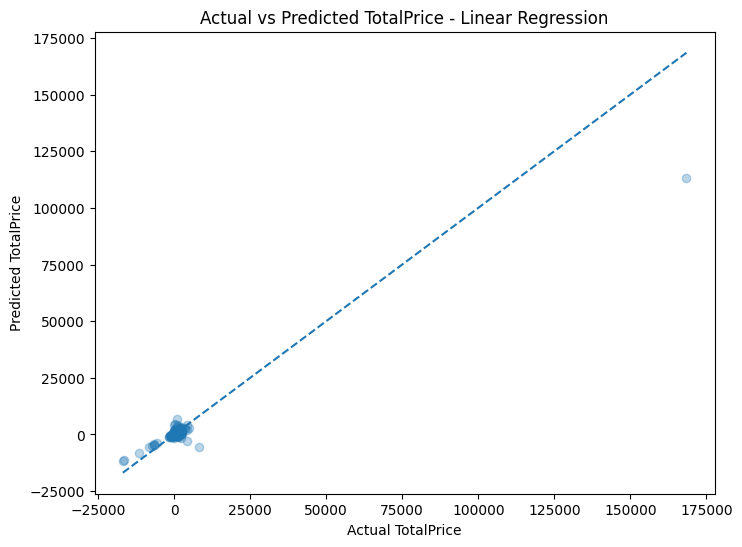

In [71]:
# Plot Actual vs. Predicted TotalPrice with a diagonal reference line (perfect prediction)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    Y_test,
    y_pred_linear,
    alpha=0.3
)

# Reference line for perfect predictions
min_value = min(Y_test.min(), y_pred_linear.min())
max_value = max(Y_test.max(), y_pred_linear.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.xlabel('Actual TotalPrice')
plt.ylabel('Predicted TotalPrice')
plt.title('Actual vs Predicted TotalPrice - Linear Regression')

plt.show()

# TASK 4

## SECTION A

In [72]:
# Inspect Monetary distribution and the tertile cut points to be used for CustomerValue

print("Monetary statistics:")
print(rfm['Monetary'].describe())

print("\nMonetary quantiles:")
print(rfm['Monetary'].quantile([0.33, 0.67]))

Monetary statistics:
count      4372.000000
mean       1893.531433
std        8218.696204
min       -4287.630000
25%         291.795000
50%         644.070000
75%        1608.335000
max      279489.020000
Name: Monetary, dtype: float64

Monetary quantiles:
0.33     365.0591
0.67    1149.8670
Name: Monetary, dtype: float64


In [73]:
# Create the CustomerValue categorical target (Low/Medium/High) using quantile binning

rfm['CustomerValue'] = pd.qcut(
    rfm['Monetary'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

print(rfm[['CustomerID', 'Monetary', 'CustomerValue']].head(10))

   CustomerID  Monetary CustomerValue
0       12346      0.00           Low
1       12347   4310.00          High
2       12348   1797.24          High
3       12349   1757.55          High
4       12350    334.40           Low
5       12352   1545.41          High
6       12353     89.00           Low
7       12354   1079.40        Medium
8       12355    459.40        Medium
9       12356   2811.43          High


In [74]:
# Check the class balance of CustomerValue

print("Customer value distribution:")
print(rfm['CustomerValue'].value_counts())

print("\nCustomer value percentages:")
print(
    rfm['CustomerValue']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Customer value distribution:
CustomerValue
Low       1458
Medium    1457
High      1457
Name: count, dtype: int64

Customer value percentages:
CustomerValue
Low       33.35
Medium    33.33
High      33.33
Name: proportion, dtype: float64


In [75]:
# Define predictors X_class (Recency, Frequency, UniqueProducts) and target Y_class

classification_features = [
    'Recency',
    'Frequency',
    'UniqueProducts'
]

X_class = rfm[classification_features]
Y_class = rfm['CustomerValue']

print("Feature matrix shape:", X_class.shape)
print("Target vector shape:", Y_class.shape)

print("\nFeatures:")
print(X_class.columns.tolist())

print("\nTarget classes:")
print(Y_class.unique())

Feature matrix shape: (4372, 3)
Target vector shape: (4372,)

Features:
['Recency', 'Frequency', 'UniqueProducts']

Target classes:
['Low', 'High', 'Medium']
Categories (3, str): ['Low' < 'Medium' < 'High']


In [76]:
# Split classification data into training and testing sets (stratified 80/20)

from sklearn.model_selection import train_test_split

X_train_class, X_test_class, Y_train_class, Y_test_class = train_test_split(
    X_class,
    Y_class,
    test_size=0.20,
    random_state=42,
    stratify=Y_class
)

print("X_train shape:", X_train_class.shape)
print("X_test shape:", X_test_class.shape)
print("Y_train shape:", Y_train_class.shape)
print("Y_test shape:", Y_test_class.shape)

print("\nTraining class distribution:")
print(Y_train_class.value_counts())

print("\nTesting class distribution:")
print(Y_test_class.value_counts())

X_train shape: (3497, 3)
X_test shape: (875, 3)
Y_train shape: (3497,)
Y_test shape: (875,)

Training class distribution:
CustomerValue
Low       1166
Medium    1166
High      1165
Name: count, dtype: int64

Testing class distribution:
CustomerValue
Low       292
High      292
Medium    291
Name: count, dtype: int64


In [77]:
# Build and train a Logistic Regression pipeline (scaling + classifier)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

classification_model = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic_regression', LogisticRegression(max_iter=1000, random_state=42))
])

classification_model.fit(X_train_class, Y_train_class)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [78]:
# Preview actual vs. predicted CustomerValue for the first 20 test customers

Y_pred_class = classification_model.predict(X_test_class)

print("First 20 actual values:")
print(Y_test_class.head(20).to_numpy())

print("\nFirst 20 predicted values:")
print(Y_pred_class[:20])

First 20 actual values:
['High' 'High' 'Medium' 'Medium' 'Low' 'High' 'Low' 'Medium' 'Low' 'High'
 'Medium' 'High' 'Low' 'Medium' 'Medium' 'High' 'High' 'Low' 'High' 'High']

First 20 predicted values:
['Low' 'Medium' 'Low' 'Low' 'Low' 'High' 'Low' 'High' 'Low' 'High'
 'Medium' 'High' 'Low' 'Low' 'Low' 'High' 'High' 'Medium' 'High' 'Low']


In [79]:
# Evaluate the classifier: accuracy, precision, recall and F1-score

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(Y_test_class, Y_pred_class)

precision = precision_score(
    Y_test_class,
    Y_pred_class,
    average='weighted'
)

recall = recall_score(
    Y_test_class,
    Y_pred_class,
    average='weighted'
)

f1 = f1_score(
    Y_test_class,
    Y_pred_class,
    average='weighted'
)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Accuracy:  0.7520
Precision: 0.7530
Recall:    0.7520
F1-score:  0.7499


In [80]:
# Build the confusion matrix for the classification model

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    Y_test_class,
    Y_pred_class,
    labels=['Low', 'Medium', 'High']
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[254  36   2]
 [ 73 179  39]
 [ 14  53 225]]


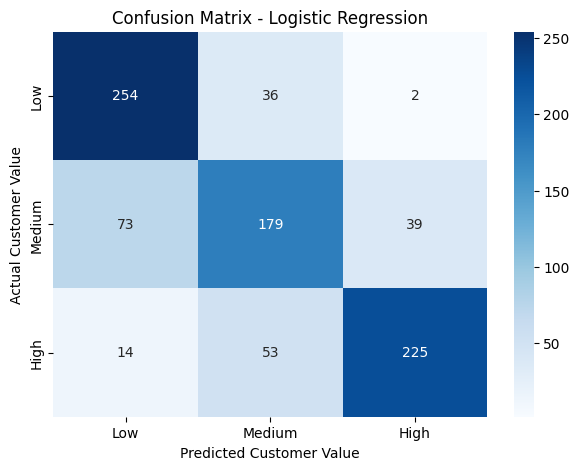

In [81]:
# Plot the confusion matrix as a heatmap

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Low', 'Medium', 'High'],
    yticklabels=['Low', 'Medium', 'High']
)

plt.xlabel('Predicted Customer Value')
plt.ylabel('Actual Customer Value')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

In [82]:
# Select the RFM-based features to be used for clustering

clustering_features = [
    'Recency',
    'Frequency',
    'Monetary',
    'AverageBasket',
    'UniqueProducts'
]

X_cluster = rfm[clustering_features]

print("Clustering feature matrix shape:", X_cluster.shape)

print("\nClustering features:")
print(X_cluster.columns.tolist())

print("\nFirst 5 rows:")
print(X_cluster.head())

Clustering feature matrix shape: (4372, 5)

Clustering features:
['Recency', 'Frequency', 'Monetary', 'AverageBasket', 'UniqueProducts']

First 5 rows:
   Recency  Frequency  Monetary  AverageBasket  UniqueProducts
0      326          2      0.00       0.000000               1
1        2          7   4310.00     615.714286             103
2       75          4   1797.24     449.310000              22
3       19          1   1757.55    1757.550000              73
4      310          1    334.40     334.400000              17


## SECTION B

In [83]:
# Check the scaled dataset that will feed into K-means

print("Scaled clustering data shape:", rfm_scaled.shape)
print("\nMean of scaled features:")
print(rfm_scaled.mean())

Scaled clustering data shape: (4372, 6)

Mean of scaled features:
CustomerID        15299.677722
Recency                   -0.0
Frequency                  0.0
Monetary                   0.0
AverageBasket             -0.0
UniqueProducts             0.0
dtype: Float64


In [84]:
# Isolate the scaled clustering features into X_cluster_scaled

X_cluster_scaled = rfm_scaled[clustering_features]

print("Scaled clustering feature matrix shape:", X_cluster_scaled.shape)

print("\nMean of scaled features:")
print(X_cluster_scaled.mean())

print("\nStandard deviation of scaled features:")
print(X_cluster_scaled.std())

Scaled clustering feature matrix shape: (4372, 5)

Mean of scaled features:
Recency          -4.225551e-17
Frequency         1.950255e-17
Monetary          1.137648e-17
AverageBasket    -7.801018e-17
UniqueProducts    1.787733e-17
dtype: float64

Standard deviation of scaled features:
Recency           1.000114
Frequency         1.000114
Monetary          1.000114
AverageBasket     1.000114
UniqueProducts    1.000114
dtype: float64


In [85]:
# Run K-means for K = 2 to 10 and record inertia and silhouette score for each K

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia_values = []
silhouette_values = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    cluster_labels = kmeans.fit_predict(X_cluster_scaled)
    
    inertia_values.append(kmeans.inertia_)
    silhouette_values.append(
        silhouette_score(X_cluster_scaled, cluster_labels)
    )

print("K values:", list(k_values))
print("\nInertia values:")
print(inertia_values)

print("\nSilhouette scores:")
print(silhouette_values)

K values: [2, 3, 4, 5, 6, 7, 8, 9, 10]

Inertia values:
[16729.351154451488, 12797.440712395395, 10390.375830191417, 8814.474655596789, 7370.207640476039, 6447.40133249333, 5696.187327803588, 5134.657175957903, 4728.98427727622]

Silhouette scores:
[0.9017948337274198, 0.39031170952261657, 0.4318994517291496, 0.44008487306485716, 0.4449028991769028, 0.43174572304374936, 0.4463077620590752, 0.35732352182430566, 0.32849434690583434]


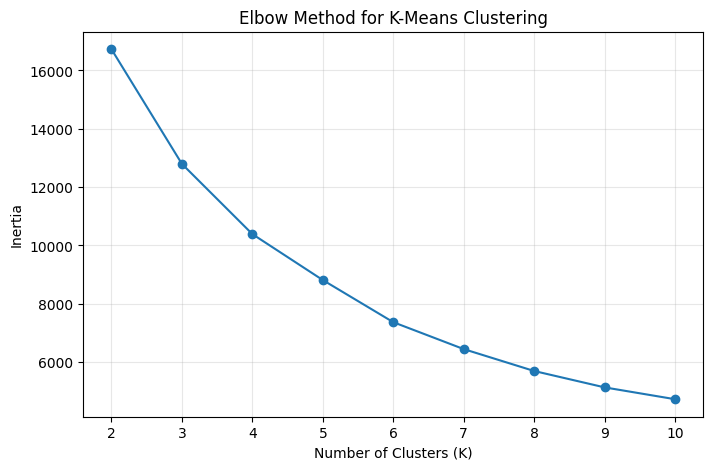

In [86]:
# Plot the Elbow curve (inertia vs. K)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    inertia_values,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for K-Means Clustering')
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)

plt.show()

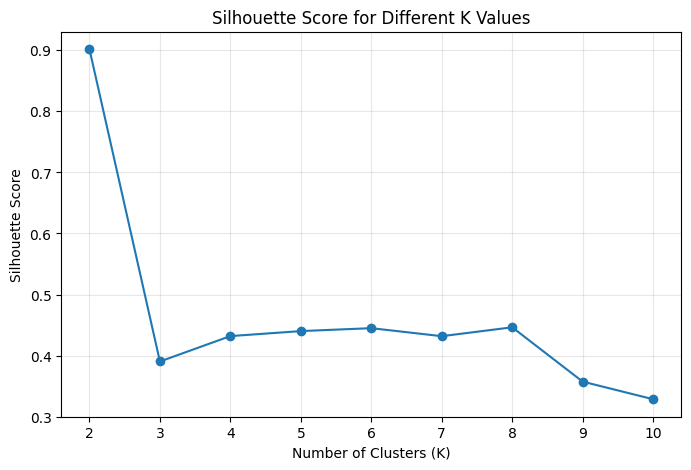

In [87]:
# Plot the Silhouette score vs. K

plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    silhouette_values,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different K Values')
plt.xticks(list(k_values))
plt.grid(True, alpha=0.3)

plt.show()

In [88]:
# Fit K-means with K=2 to inspect the extreme 2-cluster split

kmeans_2 = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

cluster_labels_2 = kmeans_2.fit_predict(X_cluster_scaled)

rfm_clustered = rfm.copy()
rfm_clustered['Cluster'] = cluster_labels_2

print("Cluster sizes:")
print(rfm_clustered['Cluster'].value_counts().sort_index())

print("\nCluster profiles:")
cluster_profile_2 = rfm_clustered.groupby('Cluster')[clustering_features].mean()

print(cluster_profile_2)

Cluster sizes:
Cluster
0    4357
1      15
Name: count, dtype: int64

Cluster profiles:
           Recency  Frequency       Monetary  AverageBasket  UniqueProducts
Cluster                                                                    
0        92.348405   4.754189    1544.768745     309.747418       58.687170
1         4.533333  98.400000  103197.466667    1692.836854      794.333333


In [89]:
# Fit K-means for K = 3, 4, 5, 6, 8 to compare candidate segmentations

k_values_profile = [3, 4, 5, 6, 8]

for k in k_values_profile:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_cluster_scaled)
    
    temp_rfm = rfm.copy()
    temp_rfm['Cluster'] = labels
    
    print(f"\n{'='*60}")
    print(f"K = {k}")
    
    print("\nCluster sizes:")
    print(temp_rfm['Cluster'].value_counts().sort_index())
    
    print("\nCluster profiles:")
    print(
        temp_rfm.groupby('Cluster')[clustering_features]
        .mean()
        .round(2)
    )


K = 3

Cluster sizes:
Cluster
0    3225
1    1132
2      15
Name: count, dtype: int64

Cluster profiles:
         Recency  Frequency   Monetary  AverageBasket  UniqueProducts
Cluster                                                              
0          39.49       5.79    1948.15         336.07           71.24
1         242.93       1.81     395.57         234.77           22.92
2           4.53      98.40  103197.47        1692.84          794.33

K = 4

Cluster sizes:
Cluster
0    2719
1     581
2      15
3    1057
Name: count, dtype: int64

Cluster profiles:
         Recency  Frequency   Monetary  AverageBasket  UniqueProducts
Cluster                                                              
0          45.49       3.83     986.42         276.26           46.12
1          23.66      14.39    6240.16         602.63          181.87
2           4.53      98.40  103197.47        1692.84          794.33
3         250.63       1.83     400.15         234.91           23.32

K = 5



In [90]:
# Fit the final K-means model with K=4

kmeans_final = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_labels_final = kmeans_final.fit_predict(X_cluster_scaled)

rfm_clustered = rfm.copy()
rfm_clustered['Cluster'] = cluster_labels_final

print("Final K-means model trained with K=4.")

print("\nCluster sizes:")
print(
    rfm_clustered['Cluster']
    .value_counts()
    .sort_index()
)

Final K-means model trained with K=4.

Cluster sizes:
Cluster
0    2719
1     581
2      15
3    1057
Name: count, dtype: int64


In [91]:
# Calculate the mean feature values (profile) for each of the 4 clusters

cluster_profile = (
    rfm_clustered
    .groupby('Cluster')[clustering_features]
    .mean()
    .round(2)
)

print("Cluster profiles:")
print(cluster_profile)

Cluster profiles:
         Recency  Frequency   Monetary  AverageBasket  UniqueProducts
Cluster                                                              
0          45.49       3.83     986.42         276.26           46.12
1          23.66      14.39    6240.16         602.63          181.87
2           4.53      98.40  103197.47        1692.84          794.33
3         250.63       1.83     400.15         234.91           23.32


In [92]:
# Calculate the size of each cluster as a percentage of all customers

cluster_percentage = (
    rfm_clustered['Cluster']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("Cluster percentage:")
print(cluster_percentage)

Cluster percentage:
Cluster
0    62.19
1    13.29
2     0.34
3    24.18
Name: proportion, dtype: float64


In [93]:
# Reduce the 5 clustering features to 2 dimensions with PCA for visualisation

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_cluster_pca = pca.fit_transform(X_cluster_scaled)

print("Original feature dimensions:", X_cluster_scaled.shape[1])
print("PCA dimensions:", X_cluster_pca.shape[1])

print("\nExplained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal explained variance:")
print(pca.explained_variance_ratio_.sum())

Original feature dimensions: 5
PCA dimensions: 2

Explained variance ratio:
[0.47344613 0.2127986 ]

Total explained variance:
0.686244730294104


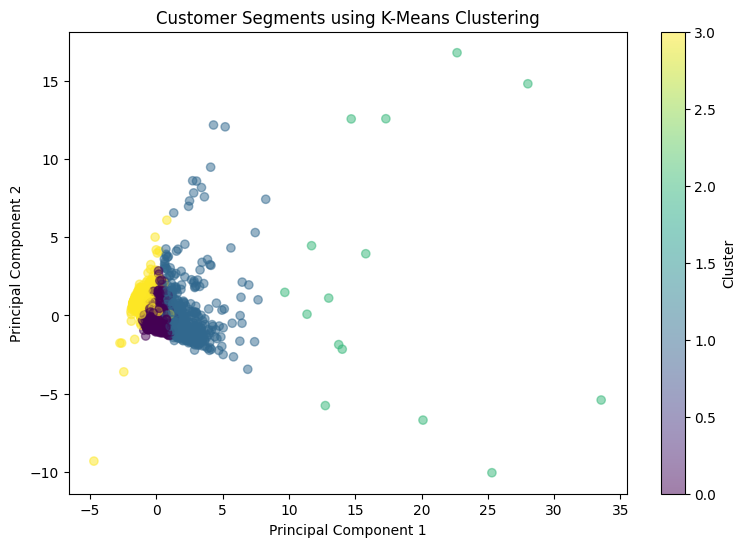

In [94]:
# Scatter plot of customers in PCA space, coloured by cluster

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    X_cluster_pca[:, 0],
    X_cluster_pca[:, 1],
    c=cluster_labels_final,
    alpha=0.5
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Customer Segments using K-Means Clustering')

plt.colorbar(scatter, label='Cluster')

plt.show()

In [95]:
# Standardise the cluster profile so features are comparable on the heatmap

from sklearn.preprocessing import StandardScaler

profile_scaler = StandardScaler()

cluster_profile_scaled = pd.DataFrame(
    profile_scaler.fit_transform(cluster_profile),
    index=cluster_profile.index,
    columns=cluster_profile.columns
)

print("Standardised cluster profiles:")
print(cluster_profile_scaled.round(2))

Standardised cluster profiles:
         Recency  Frequency  Monetary  AverageBasket  UniqueProducts
Cluster                                                             
0          -0.36      -0.64     -0.61          -0.72           -0.69
1          -0.58      -0.38     -0.49          -0.17           -0.25
2          -0.77       1.72      1.73           1.68            1.70
3           1.71      -0.69     -0.63          -0.79           -0.76


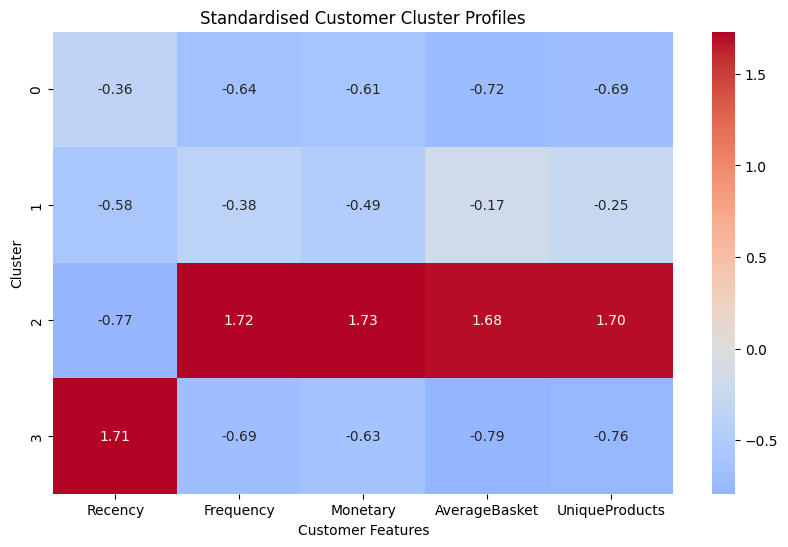

In [96]:
# Plot the standardised cluster profile as a heatmap

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.heatmap(
    cluster_profile_scaled,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Standardised Customer Cluster Profiles")
plt.xlabel("Customer Features")
plt.ylabel("Cluster")

plt.show()

In [97]:
# Calculate cluster counts and percentages for the bar chart

cluster_counts = rfm_clustered['Cluster'].value_counts().sort_index()

cluster_percentages = (
    cluster_counts / len(rfm_clustered) * 100
)

cluster_summary = pd.DataFrame({
    'Customers': cluster_counts,
    'Percentage': cluster_percentages
})

print(cluster_summary.round(2))

         Customers  Percentage
Cluster                       
0             2719       62.19
1              581       13.29
2               15        0.34
3             1057       24.18


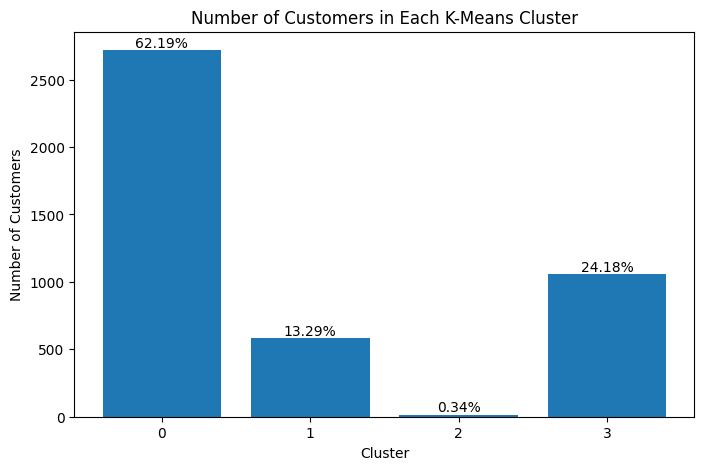

In [98]:
# Bar chart of the number of customers per cluster

plt.figure(figsize=(8, 5))

bars = plt.bar(
    cluster_summary.index.astype(str),
    cluster_summary['Customers']
)

plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.title('Number of Customers in Each K-Means Cluster')

for bar, percentage in zip(bars, cluster_summary['Percentage']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{percentage:.2f}%',
        ha='center',
        va='bottom'
    )

plt.show()

In [99]:
# Build the final cluster profile table (features + customer counts + percentages)

final_cluster_profile = cluster_profile.copy()

final_cluster_profile['Customers'] = cluster_counts
final_cluster_profile['Percentage'] = cluster_percentages

final_cluster_profile = final_cluster_profile[
    [
        'Customers',
        'Percentage',
        'Recency',
        'Frequency',
        'Monetary',
        'AverageBasket',
        'UniqueProducts'
    ]
]

print(final_cluster_profile.round(2))

         Customers  Percentage  Recency  Frequency   Monetary  AverageBasket  \
Cluster                                                                        
0             2719       62.19    45.49       3.83     986.42         276.26   
1              581       13.29    23.66      14.39    6240.16         602.63   
2               15        0.34     4.53      98.40  103197.47        1692.84   
3             1057       24.18   250.63       1.83     400.15         234.91   

         UniqueProducts  
Cluster                  
0                 46.12  
1                181.87  
2                794.33  
3                 23.32  


# TASK 5

In [100]:
# Aggregate TotalPrice by month to get net monthly transaction value

monthly_revenue = (
    df_clean
    .set_index('InvoiceDate')
    .resample('ME')['TotalPrice']
    .sum()
    .reset_index()
)
print(monthly_revenue)

   InvoiceDate   TotalPrice
0   2010-12-31   746723.610
1   2011-01-31   558448.560
2   2011-02-28   497026.410
3   2011-03-31   682013.980
4   2011-04-30   492367.841
5   2011-05-31   722094.100
6   2011-06-30   689977.230
7   2011-07-31   680156.991
8   2011-08-31   703510.580
9   2011-09-30  1017596.682
10  2011-10-31  1069368.230
11  2011-11-30  1456145.800
12  2011-12-31   432701.060


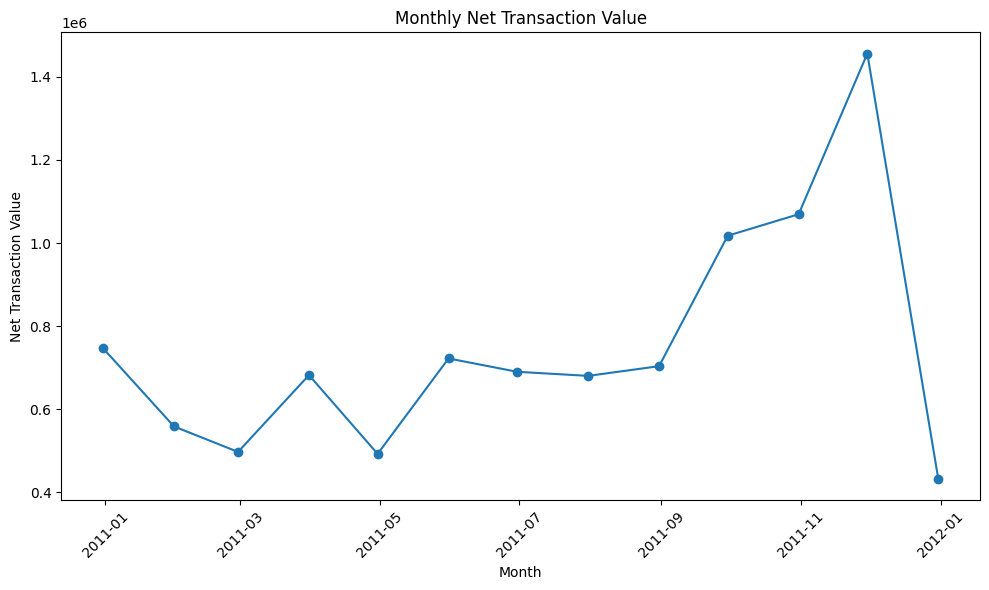

In [101]:
# Plot monthly net transaction value over time (Figure 1)

plt.figure(figsize=(10, 6))

plt.plot(
    monthly_revenue['InvoiceDate'],
    monthly_revenue['TotalPrice'],
    marker='o'
)
plt.xlabel('Month')
plt.ylabel('Net Transaction Value')
plt.title('Monthly Net Transaction Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [102]:
# Aggregate TotalPrice by product to find the top products by revenue

product_revenue = (
    df_clean
    .groupby(['StockCode', 'Description'])['TotalPrice']
    .sum()
    .reset_index()
    .sort_values('TotalPrice', ascending=False)
)

print(product_revenue.head(10))

     StockCode                         Description  TotalPrice
4323       DOT                      DOTCOM POSTAGE   206245.48
1318     22423            REGENCY CAKESTAND 3 TIER   164459.49
2777     47566                       PARTY BUNTING    98243.88
3939    85123A  WHITE HANGING HEART T-LIGHT HOLDER    97659.94
3926    85099B             JUMBO BAG RED RETROSPOT    92175.79
2031     23084                  RABBIT NIGHT LIGHT    66661.63
4326      POST                             POSTAGE    66230.64
991      22086     PAPER CHAIN KIT 50'S CHRISTMAS     63715.24
2992     84879       ASSORTED COLOUR BIRD ORNAMENT    58792.42
2849     79321                       CHILLI LIGHTS    53746.66


In [103]:
# Repeat the product ranking, excluding non-product stock codes (DOT, POST)

non_product_codes = ['DOT', 'POST']

product_revenue = (
    df_clean[
        ~df_clean['StockCode'].isin(non_product_codes)
    ]
    .groupby(['StockCode', 'Description'])['TotalPrice']
    .sum()
    .reset_index()
    .sort_values('TotalPrice', ascending=False)
)

print(product_revenue.head(10))

     StockCode                         Description  TotalPrice
1318     22423            REGENCY CAKESTAND 3 TIER   164459.49
2777     47566                       PARTY BUNTING    98243.88
3939    85123A  WHITE HANGING HEART T-LIGHT HOLDER    97659.94
3926    85099B             JUMBO BAG RED RETROSPOT    92175.79
2031     23084                  RABBIT NIGHT LIGHT    66661.63
991      22086     PAPER CHAIN KIT 50'S CHRISTMAS     63715.24
2992     84879       ASSORTED COLOUR BIRD ORNAMENT    58792.42
2849     79321                       CHILLI LIGHTS    53746.66
2301     23298                      SPOTTY BUNTING    42030.67
1285     22386             JUMBO BAG PINK POLKADOT    41584.43


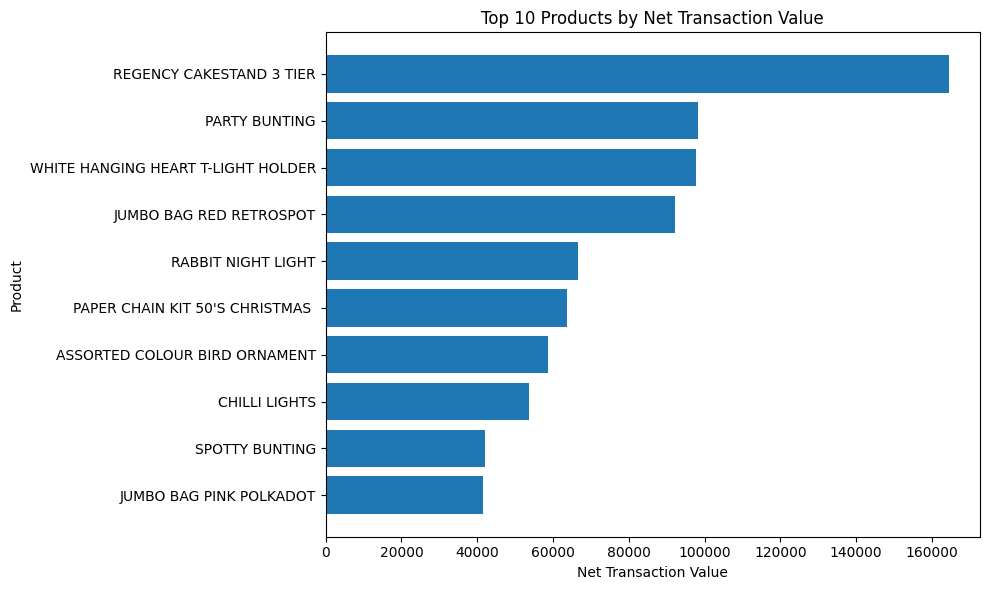

In [104]:
# Horizontal bar chart of the top 10 products by net transaction value (Figure 2)

top_products = product_revenue.head(10).sort_values('TotalPrice')

plt.figure(figsize=(10, 6))

plt.barh(
    top_products['Description'],
    top_products['TotalPrice']
)

plt.xlabel('Net Transaction Value')
plt.ylabel('Product')
plt.title('Top 10 Products by Net Transaction Value')

plt.tight_layout()

plt.show()

In [105]:
# Aggregate TotalPrice by country to find the top countries by revenue

country_revenue = (
    df_clean
    .groupby('Country')['TotalPrice']
    .sum()
    .reset_index()
    .sort_values('TotalPrice', ascending=False)
)

print(country_revenue.head(15))

            Country   TotalPrice
36   United Kingdom  8189252.304
24      Netherlands   284661.540
10             EIRE   262993.380
14          Germany   221509.470
13           France   197317.110
0         Australia   137009.770
33      Switzerland    56363.050
31            Spain    54756.030
3           Belgium    40910.960
32           Sweden    36585.410
20            Japan    35340.620
25           Norway    35163.460
27         Portugal    29302.970
12          Finland    22326.740
6   Channel Islands    20076.390


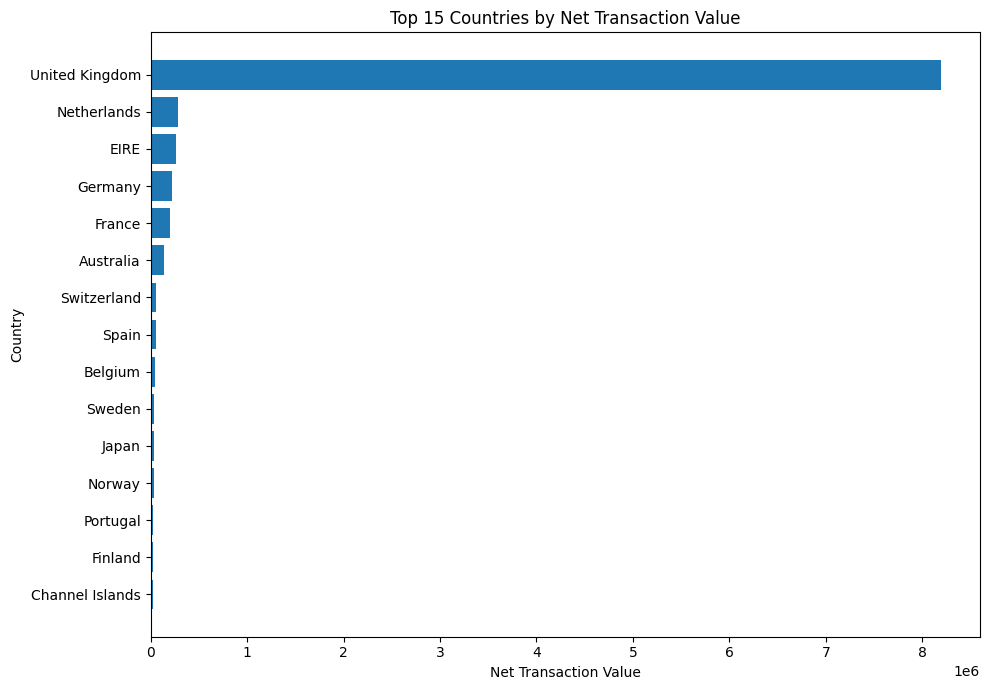

In [106]:
# Horizontal bar chart of the top 15 countries by net transaction value (Figure 3)

top_countries = country_revenue.head(15).sort_values('TotalPrice')

plt.figure(figsize=(10, 7))

plt.barh(
    top_countries['Country'],
    top_countries['TotalPrice']
)

plt.xlabel('Net Transaction Value')
plt.ylabel('Country')
plt.title('Top 15 Countries by Net Transaction Value')

plt.tight_layout()

plt.show()

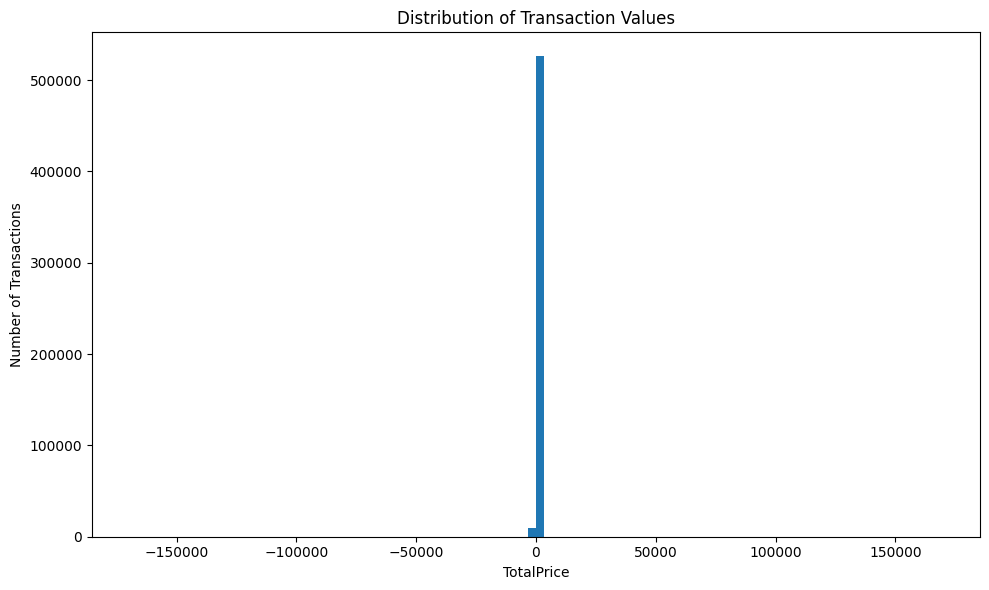

In [107]:
# First version of the TotalPrice histogram - kept to show the axis-scaling problem discussed in the report

plt.figure(figsize=(10, 6))

plt.hist(
    df_clean['TotalPrice'],
    bins=100
)

plt.xlabel('TotalPrice')
plt.ylabel('Number of Transactions')
plt.title('Distribution of Transaction Values')

plt.tight_layout()

plt.show()

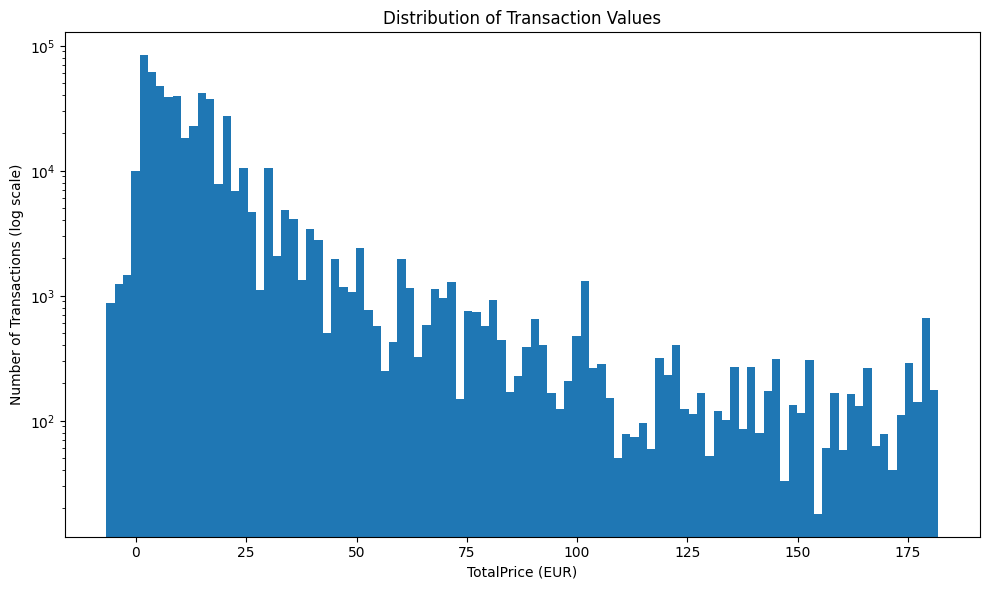

In [108]:
# Corrected histogram: clipped to the 1st-99th percentile with a log y-axis, to reveal the true shape of the distribution (Figure 4)

low, high = df_clean['TotalPrice'].quantile([0.01, 0.99])

plt.figure(figsize=(10, 6))
plt.hist(df_clean['TotalPrice'], bins=100, range=(low, high))
plt.yscale('log')
plt.xlabel('TotalPrice (EUR)')
plt.ylabel('Number of Transactions (log scale)')
plt.title('Distribution of Transaction Values')
plt.tight_layout()
plt.show()